**Objective:** Predict whether a bank customer will subscribe to a term deposit as a result of a marketing campaign.

### What we will do:
1. Load and explore the dataset (EDA)
2. Encode all categorical features properly
3. Train two classification models: Logistic Regression & Random Forest
4. Evaluate models using Confusion Matrix, F1-Score, and ROC Curve
5. Use SHAP to explain 5 individual model predictions (Explainable AI)

---


## 📦 Section 1 — Import Libraries

In [5]:
# We import all the tools we need at the start
# This is standard practice so everything is available throughout the notebook

import pandas as pd                          # for loading and manipulating data tables
import numpy as np                           # for numerical calculations
import matplotlib.pyplot as plt              # for drawing graphs and charts
import matplotlib.patches as mpatches       # for custom legend patches
import seaborn as sns                        # for prettier statistical visualizations
import warnings
import sys, subprocess
import shap
warnings.filterwarnings("ignore")            # suppress minor warnings to keep output clean
# SHAP is optional — try to import, and install automatically if missing (works in Jupyter)
try:
    import shap                                # SHapley Additive exPlanations — for XAI
except Exception:
    print("SHAP not found. Installing shap via pip... (this may take a minute)")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])

from sklearn.preprocessing import LabelEncoder          # converts text categories to numbers
from sklearn.model_selection import train_test_split    # splits dataset into train and test portions
from sklearn.linear_model import LogisticRegression     # simple linear classifier
from sklearn.ensemble import RandomForestClassifier     # ensemble of decision trees
from sklearn.metrics import (
    confusion_matrix,           # table of TP, FP, TN, FN counts
    classification_report,      # precision, recall, F1-score summary
    roc_curve,                  # data points for plotting the ROC curve
    roc_auc_score,              # single number summarising the ROC curve
    f1_score, accuracy_score,
    precision_score, recall_score
)

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 📂 Section 2 — Load & Explore the Dataset

The dataset comes from the **UCI Bank Marketing** repository. Each row is one phone call to a customer. The target column `y` tells us whether the customer said **yes** or **no** to a term deposit.

> **Note:** The file uses `;` (semicolons) as column separators instead of commas, so we pass `sep=";"`.

In [6]:
# Load the CSV — the separator is semicolon (;), not comma
df = pd.read_csv(r"D:\Data Analyst\internship\Task 2\New folder\bank.csv", sep=";")

print("=" * 55)
print("BASIC DATASET INFO")
print("=" * 55)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print()

# First 5 rows give us a feel for the data
print("First 5 rows:")
df.head()


BASIC DATASET INFO
Shape: 4521 rows × 17 columns

First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [7]:
# .info() shows column names, data types, and non-null counts
# It's the fastest way to spot missing values and wrong data types
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4521 non-null   int64
 1   job        4521 non-null   str  
 2   marital    4521 non-null   str  
 3   education  4521 non-null   str  
 4   default    4521 non-null   str  
 5   balance    4521 non-null   int64
 6   housing    4521 non-null   str  
 7   loan       4521 non-null   str  
 8   contact    4521 non-null   str  
 9   day        4521 non-null   int64
 10  month      4521 non-null   str  
 11  duration   4521 non-null   int64
 12  campaign   4521 non-null   int64
 13  pdays      4521 non-null   int64
 14  previous   4521 non-null   int64
 15  poutcome   4521 non-null   str  
 16  y          4521 non-null   str  
dtypes: int64(7), str(10)
memory usage: 600.6 KB


In [8]:
# .describe() gives statistics for numeric columns
# min, max, mean, std help us spot outliers and skewed distributions
df.describe().round(2)


,age,balance,day,duration,campaign,pdays,previous
count,4521.00,4521.00,4521.00,4521.00,4521.00,4521.00,4521.00
mean,41.17,1422.66,15.92,263.96,2.79,39.77,0.54
std,10.58,3009.64,8.25,259.86,3.11,100.12,1.69
min,19.00,-3313.00,1.00,4.00,1.00,-1.00,0.00
25%,33.00,69.00,9.00,104.00,1.00,-1.00,0.00
50%,39.00,444.00,16.00,185.00,2.00,-1.00,0.00
75%,49.00,1480.00,21.00,329.00,3.00,-1.00,0.00
max,87.00,71188.00,31.00,3025.00,50.00,871.00,25.00


In [9]:
# Check for missing values — must be 0 for all columns before training
print("Missing values per column:")
print(df.isnull().sum())
print()

# How many customers subscribed vs. did not?
print("Target variable distribution:")
print(df['y'].value_counts())
print(f"\nSubscription Rate: {df['y'].value_counts(normalize=True)['yes']*100:.1f}%")

# The dataset is imbalanced — far more 'no' than 'yes'
# We will handle this with class_weight='balanced' when training models


Missing values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Target variable distribution:
y
no     4000
yes     521
Name: count, dtype: int64

Subscription Rate: 11.5%


## 📊 Section 3 — Exploratory Data Analysis (EDA)

Before building models, we visualize the data. This helps us understand:
- Which features are related to subscriptions
- Whether there is class imbalance
- What the distributions look like

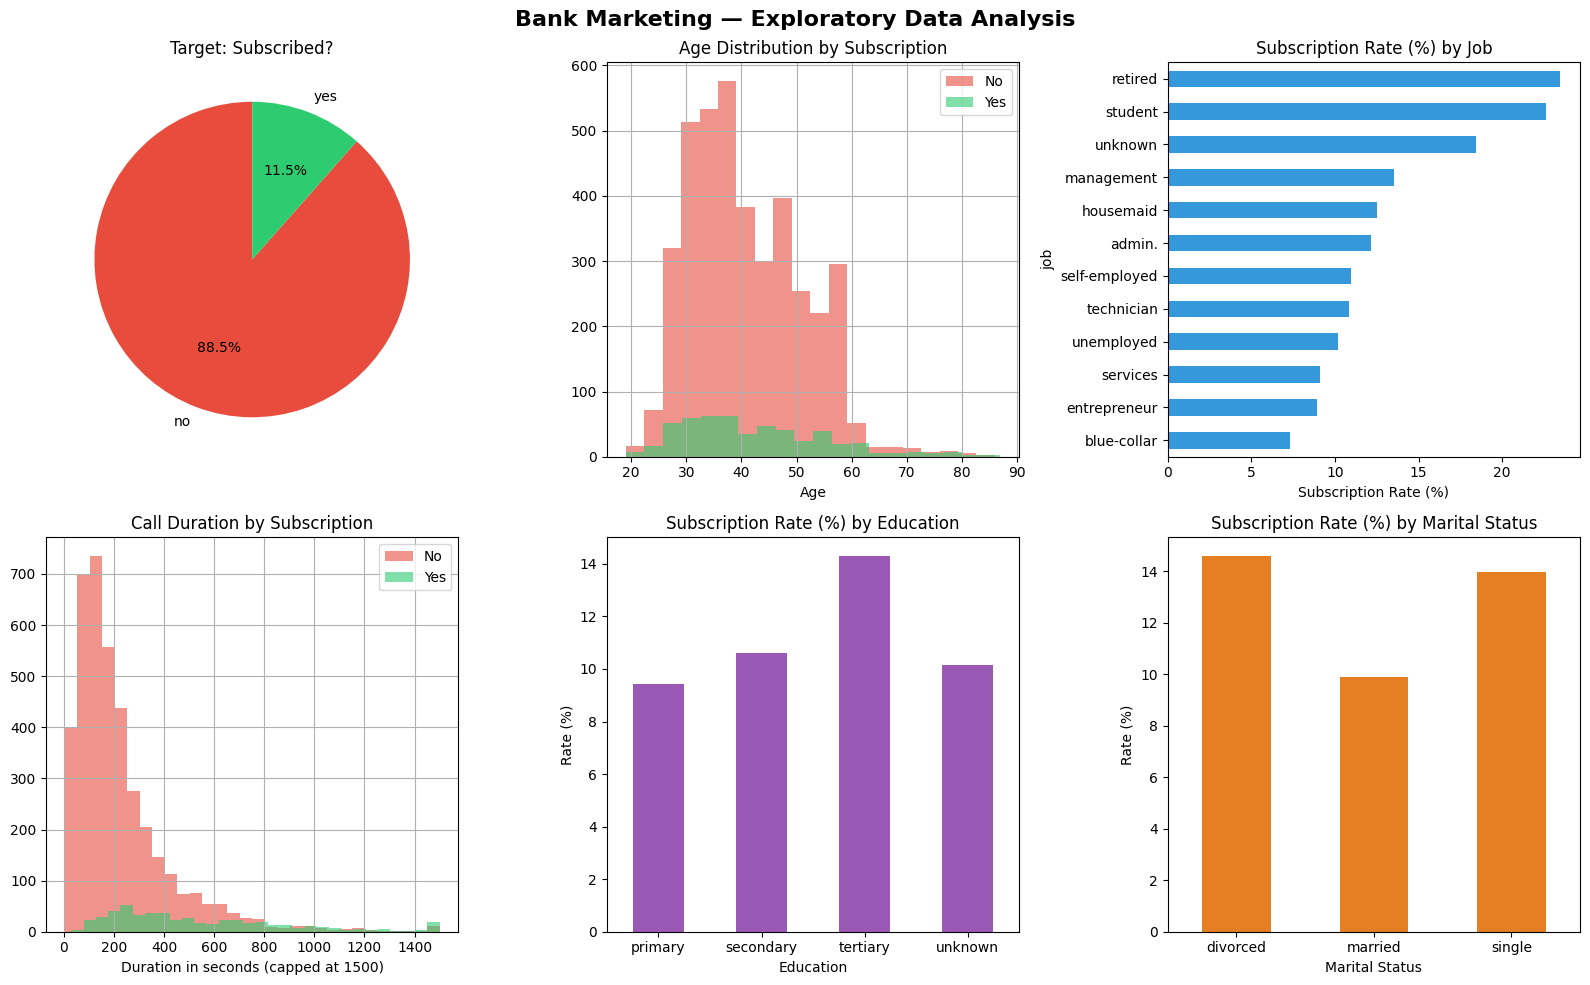

In [10]:
# Create a 2×3 grid of charts to explore the dataset visually
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Bank Marketing — Exploratory Data Analysis", fontsize=16, fontweight='bold')

colors = ['#e74c3c', '#2ecc71']   # red = No, green = Yes

# Chart 1: Pie chart of target class
# Shows how imbalanced the dataset is (88.5% No vs 11.5% Yes)
counts = df['y'].value_counts()
axes[0, 0].pie(counts, labels=counts.index, autopct='%1.1f%%',
               colors=colors, startangle=90)
axes[0, 0].set_title("Target: Subscribed?")

# Chart 2: Age histogram by subscription outcome
# Older customers (50+) tend to subscribe more
df[df['y']=='no']['age'].hist(ax=axes[0, 1], alpha=0.6, color='#e74c3c',
                               label='No', bins=20)
df[df['y']=='yes']['age'].hist(ax=axes[0, 1], alpha=0.6, color='#2ecc71',
                                label='Yes', bins=20)
axes[0, 1].set_title("Age Distribution by Subscription")
axes[0, 1].set_xlabel("Age"); axes[0, 1].legend()

# Chart 3: Subscription rate per job type
# Retired and students have highest subscription rates
job_sub = df.groupby('job')['y'].apply(lambda x: (x=='yes').mean()*100).sort_values()
job_sub.plot(kind='barh', ax=axes[0, 2], color='#3498db')
axes[0, 2].set_title("Subscription Rate (%) by Job")
axes[0, 2].set_xlabel("Subscription Rate (%)")

# Chart 4: Call duration distribution
# Longer calls strongly correlate with subscriptions
df[df['y']=='no']['duration'].clip(upper=1500).hist(ax=axes[1, 0],
    alpha=0.6, color='#e74c3c', label='No', bins=30)
df[df['y']=='yes']['duration'].clip(upper=1500).hist(ax=axes[1, 0],
    alpha=0.6, color='#2ecc71', label='Yes', bins=30)
axes[1, 0].set_title("Call Duration by Subscription")
axes[1, 0].set_xlabel("Duration in seconds (capped at 1500)"); axes[1, 0].legend()

# Chart 5: Education level vs subscription rate
edu_sub = df.groupby('education')['y'].apply(lambda x: (x=='yes').mean()*100)
edu_sub.plot(kind='bar', ax=axes[1, 1], color='#9b59b6', rot=0)
axes[1, 1].set_title("Subscription Rate (%) by Education")
axes[1, 1].set_xlabel("Education"); axes[1, 1].set_ylabel("Rate (%)")

# Chart 6: Marital status vs subscription rate
mar_sub = df.groupby('marital')['y'].apply(lambda x: (x=='yes').mean()*100)
mar_sub.plot(kind='bar', ax=axes[1, 2], color='#e67e22', rot=0)
axes[1, 2].set_title("Subscription Rate (%) by Marital Status")
axes[1, 2].set_xlabel("Marital Status"); axes[1, 2].set_ylabel("Rate (%)")

plt.tight_layout()
plt.show()


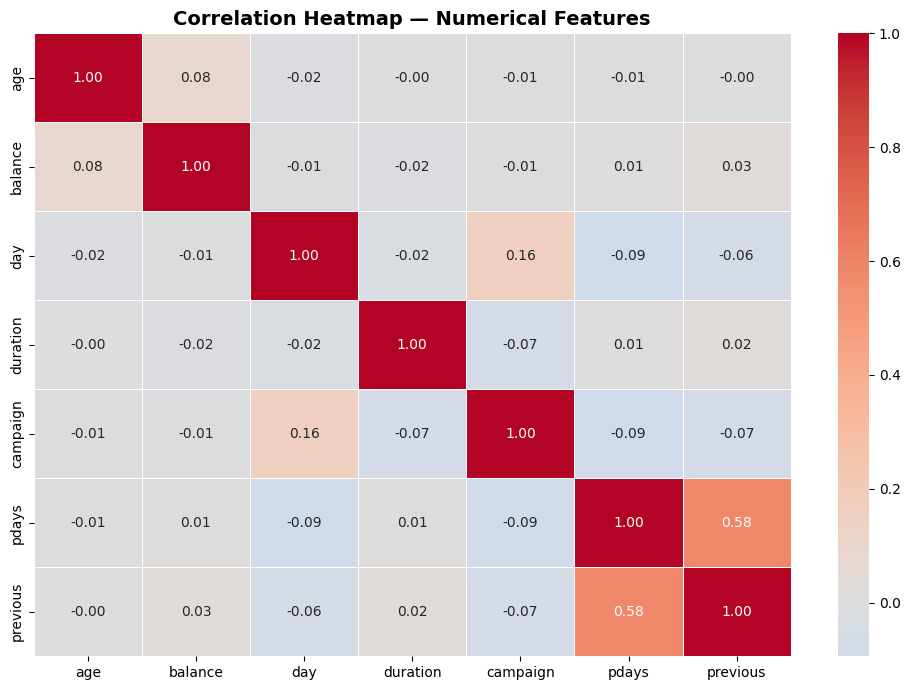

In [11]:
# Correlation heatmap for numerical features
# Values close to 1 or -1 mean the two features are strongly related
# High correlation between input features can hurt some models (multicollinearity)
num_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 7))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title("Correlation Heatmap — Numerical Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 🔡 Section 4 — Feature Encoding

Machine learning models cannot work with text. We convert every text column to numbers using **LabelEncoder**, which assigns an integer to each unique category.

| Original | Encoded |
|----------|---------|
| `"no"` | `0` |
| `"yes"` | `1` |
| `"married"` | `1` |
| `"single"` | `2` |


In [26]:
# Create a copy so we never modify the original dataframe
df_encoded = df.copy()

# Find all text (object/str) columns
cat_cols = df_encoded.select_dtypes(include='object').columns.tolist()
print(f"Columns to encode: {cat_cols}")
print()

# LabelEncoder assigns a unique integer to each unique text value
le = LabelEncoder()
for col in cat_cols:
    original_sample = df[col].unique()[:3]          # show first 3 original values
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoded_sample  = df_encoded[col].unique()[:3]   # show first 3 encoded values
    print(f"  '{col}': {list(original_sample)} → {list(encoded_sample)}")

print()
print("Encoded dataframe (first 3 rows):")
df_encoded.head(3)


Columns to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

  'job': ['unemployed', 'services', 'management'] → [np.int64(10), np.int64(7), np.int64(4)]
  'marital': ['married', 'single', 'divorced'] → [np.int64(1), np.int64(2), np.int64(0)]
  'education': ['primary', 'secondary', 'tertiary'] → [np.int64(0), np.int64(1), np.int64(2)]
  'default': ['no', 'yes'] → [np.int64(0), np.int64(1)]
  'housing': ['no', 'yes'] → [np.int64(0), np.int64(1)]
  'loan': ['no', 'yes'] → [np.int64(0), np.int64(1)]
  'contact': ['cellular', 'unknown', 'telephone'] → [np.int64(0), np.int64(2), np.int64(1)]
  'month': ['oct', 'may', 'apr'] → [np.int64(10), np.int64(8), np.int64(0)]
  'poutcome': ['unknown', 'failure', 'other'] → [np.int64(3), np.int64(0), np.int64(1)]
  'y': ['no', 'yes'] → [np.int64(0), np.int64(1)]

Encoded dataframe (first 3 rows):


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,10,1,0,0,1787,0,0,0,19,10,79,1,-1,0,3,0
1,33,7,1,1,0,4789,1,1,0,11,8,220,1,339,4,0,0
2,35,4,2,2,0,1350,1,0,0,16,0,185,1,330,1,0,0


## ✂️ Section 5 — Prepare Features & Split Data

- **X** = all columns except the target → what we feed into the model  
- **y** = the target column `y` (0 = no, 1 = yes) → what we want to predict  
- We split 80% for **training** and 20% for **testing**  
- `stratify=y` ensures the yes/no ratio is preserved in both splits

In [13]:
# X = input features (everything except the label we want to predict)
# y = output label (0 = did not subscribe, 1 = subscribed)
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

print(f"Feature matrix X: {X.shape}")
print(f"Target vector y:  {y.shape}")
print(f"Class balance — No (0): {(y==0).sum()}, Yes (1): {(y==1).sum()}")

# train_test_split randomly divides the data
# test_size=0.2  → 20% of data goes to testing (model never sees this during training)
# random_state=42 → fixed seed, so results are the same every run
# stratify=y      → keeps the same yes/no class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing  samples: {X_test.shape[0]}")


Feature matrix X: (4521, 16)
Target vector y:  (4521,)
Class balance — No (0): 4000, Yes (1): 521

Training samples: 3616
Testing  samples: 905


## 🤖 Section 6 — Train Models

### Model 1: Logistic Regression
A simple, fast, and highly interpretable linear classifier. Good baseline model.

### Model 2: Random Forest
An ensemble of many decision trees. More powerful, handles non-linear patterns well.

In [14]:
# ── LOGISTIC REGRESSION ──────────────────────────────────────
# max_iter=1000 → give the optimizer enough steps to find a solution
# class_weight='balanced' → the model pays extra attention to the minority class (yes)
#   because there are ~8× more 'no' samples than 'yes' samples
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)    # train: model learns the patterns in training data

y_pred_lr = lr.predict(X_test)          # predict class labels (0 or 1)
y_prob_lr = lr.predict_proba(X_test)[:, 1]  # predict probability of class 1 (yes)

print("LOGISTIC REGRESSION — Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred_lr, target_names=['No', 'Yes']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")


LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

          No       0.96      0.79      0.86       801
         Yes       0.31      0.73      0.43       104

    accuracy                           0.78       905
   macro avg       0.63      0.76      0.65       905
weighted avg       0.88      0.78      0.81       905

ROC-AUC Score: 0.8467


In [15]:
# ── RANDOM FOREST ────────────────────────────────────────────
# n_estimators=100 → build 100 decision trees and combine their votes
# random_state=42  → reproducible results
# class_weight='balanced' → same reason as Logistic Regression above
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

print("RANDOM FOREST — Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred_rf, target_names=['No', 'Yes']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")


RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

          No       0.90      0.98      0.94       801
         Yes       0.54      0.18      0.27       104

    accuracy                           0.89       905
   macro avg       0.72      0.58      0.61       905
weighted avg       0.86      0.89      0.86       905

ROC-AUC Score: 0.9053


## 📉 Section 7 — Confusion Matrices

A **Confusion Matrix** breaks predictions into 4 buckets:

| | Predicted: No | Predicted: Yes |
|---|---|---|
| **Actual: No** | True Negative (✅) | False Positive (❌) |
| **Actual: Yes** | False Negative (❌) | True Positive (✅) |

We want high True Positives and True Negatives.

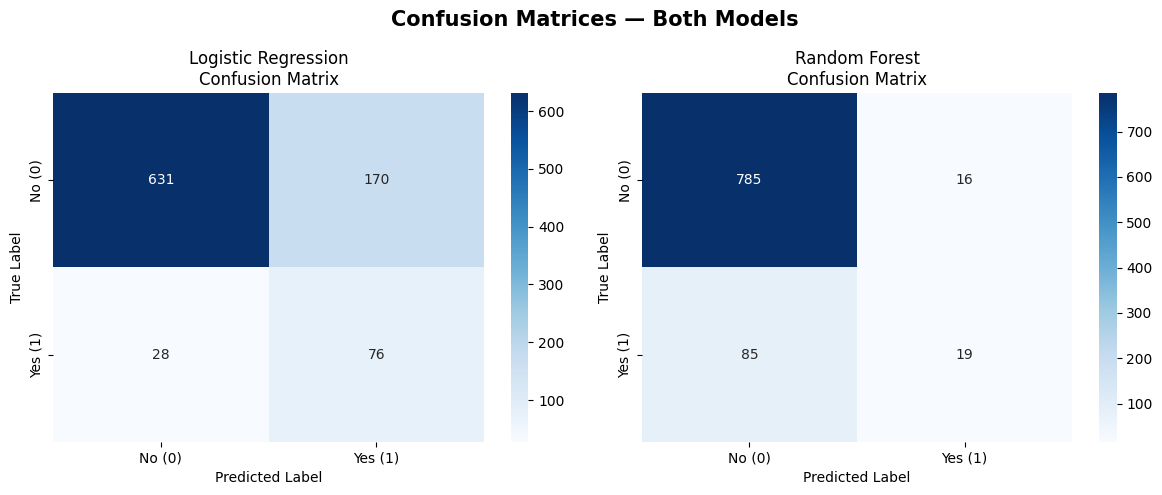

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Confusion Matrices — Both Models", fontsize=15, fontweight='bold')

for ax, y_pred, title in zip(axes,
                              [y_pred_lr, y_pred_rf],
                              ['Logistic Regression', 'Random Forest']):
    # confusion_matrix computes the TP, FP, TN, FN table
    cm = confusion_matrix(y_test, y_pred)
    # annot=True writes the numbers inside each cell
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No (0)', 'Yes (1)'],
                yticklabels=['No (0)', 'Yes (1)'])
    ax.set_title(f"{title}\nConfusion Matrix")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()


## 📈 Section 8 — ROC Curves

The **ROC Curve** plots:
- **X-axis:** False Positive Rate (how often we wrongly predict Yes)
- **Y-axis:** True Positive Rate (how often we correctly predict Yes)

**AUC (Area Under Curve):** closer to 1.0 = better model. 0.5 = random guessing.

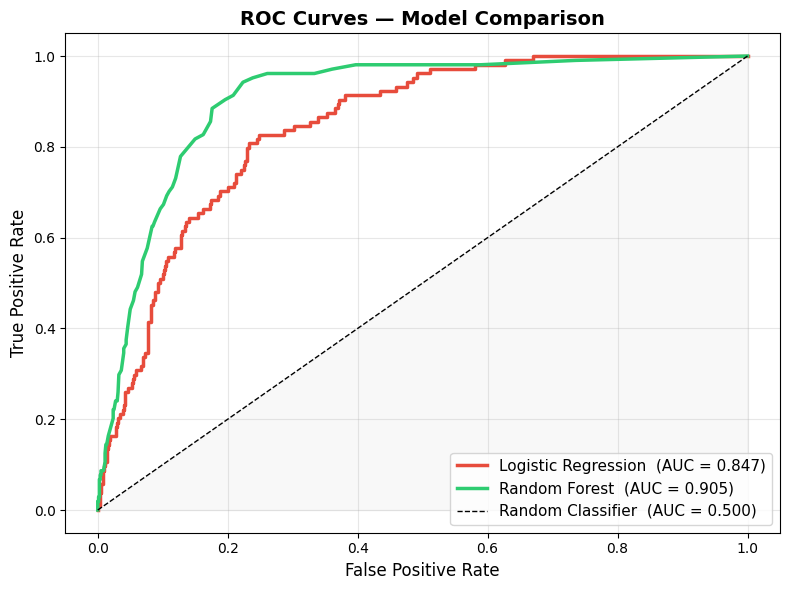

In [17]:
plt.figure(figsize=(8, 6))

# Plot ROC curve for each model
for y_prob, label, color in [
    (y_prob_lr, 'Logistic Regression', '#e74c3c'),
    (y_prob_rf, 'Random Forest',       '#2ecc71'),
]:
    # roc_curve returns false positive rates, true positive rates, and thresholds
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, lw=2.5,
             label=f"{label}  (AUC = {auc:.3f})")

# Diagonal dashed line = random classifier (AUC = 0.5) — our baseline to beat
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier  (AUC = 0.500)')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves — Model Comparison", fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 🌳 Section 9 — Feature Importance (Random Forest)

Random Forest can tell us which features it relied on most when making decisions. Higher importance = more useful for prediction.

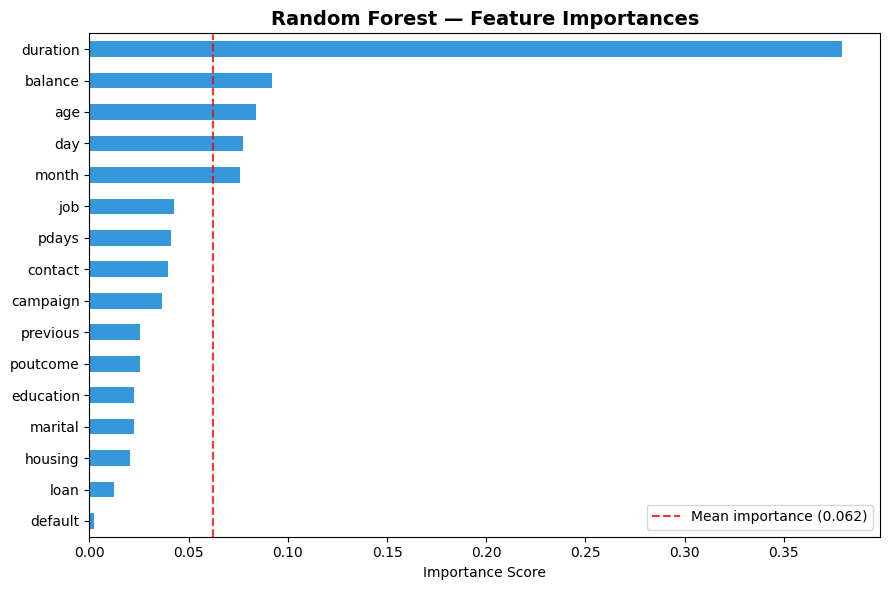


Top 5 most important features:
duration    0.3795
balance     0.0918
age         0.0840
day         0.0776
month       0.0760
dtype: float64


In [18]:
# feature_importances_ is computed internally by Random Forest
# It measures how much each feature reduces impurity across all trees
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=True)  # sort for horizontal bar chart

plt.figure(figsize=(9, 6))
bars = importances_sorted.plot(kind='barh', color='#3498db')
# Add a red line for the average importance as a reference
plt.axvline(x=importances.mean(), color='red', linestyle='--',
            alpha=0.8, label=f'Mean importance ({importances.mean():.3f})')
plt.title("Random Forest — Feature Importances", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score")
plt.legend()
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importances.sort_values(ascending=False).head().round(4))


## 🔍 Section 10 — SHAP Explainability (Explainable AI)

**SHAP = SHapley Additive exPlanations**

SHAP answers: *"Why did the model predict this specific result for this specific customer?"*

- 🔴 **Positive SHAP value** → pushes prediction toward **YES** (subscribe)  
- 🔵 **Negative SHAP value** → pushes prediction toward **NO** (don't subscribe)  
- **Magnitude** = how strongly the feature influenced the prediction

In [19]:
# TreeExplainer is the fastest SHAP method for tree-based models like Random Forest
explainer = shap.TreeExplainer(rf)

# We compute SHAP values for 50 test samples (small for speed)
X_sample = X_test.iloc[:50]
shap_values = explainer.shap_values(X_sample)

# Handle different SHAP version output shapes
import numpy as np
sv_raw = np.array(shap_values)
if sv_raw.ndim == 3:
    sv = sv_raw[:, :, 1]   # newer SHAP: (samples, features, classes) → take class 1 (yes)
else:
    sv = sv_raw[1]          # older SHAP: [classes][samples, features] → take class 1 (yes)

print(f"SHAP values computed for {len(X_sample)} test samples")
print(f"SHAP values shape: {sv.shape}")


SHAP values computed for 50 test samples
SHAP values shape: (50, 16)


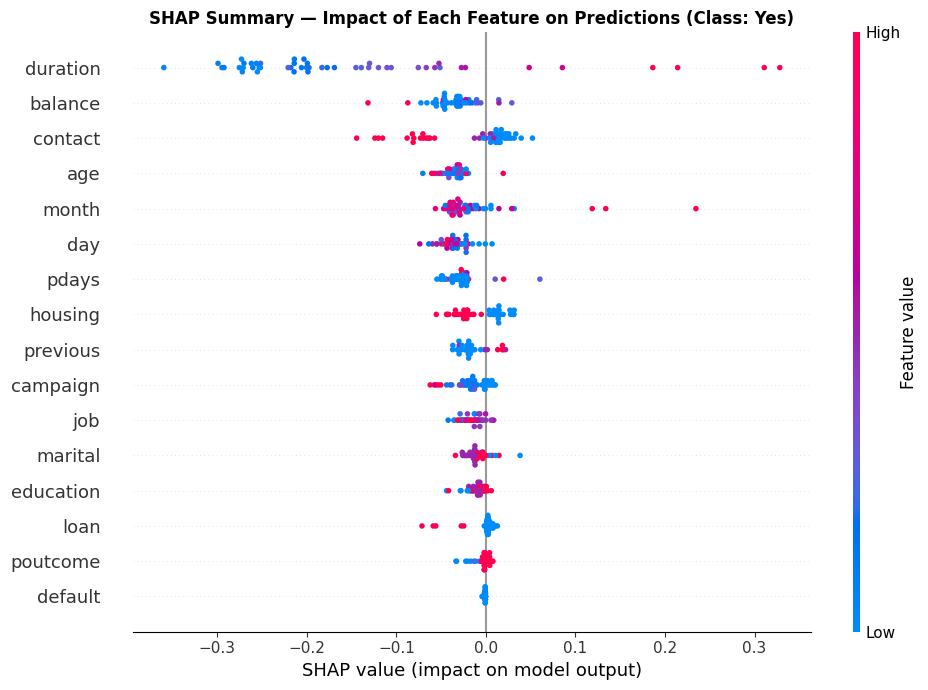

In [20]:
# SHAP Summary Plot (dot plot)
# Each dot = one customer's SHAP value for one feature
# Color = feature value (red = high, blue = low)
# Position on X axis = how much it pushed the prediction
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_sample,
                  feature_names=X.columns.tolist(),
                  show=False, plot_size=None)
plt.title("SHAP Summary — Impact of Each Feature on Predictions (Class: Yes)",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


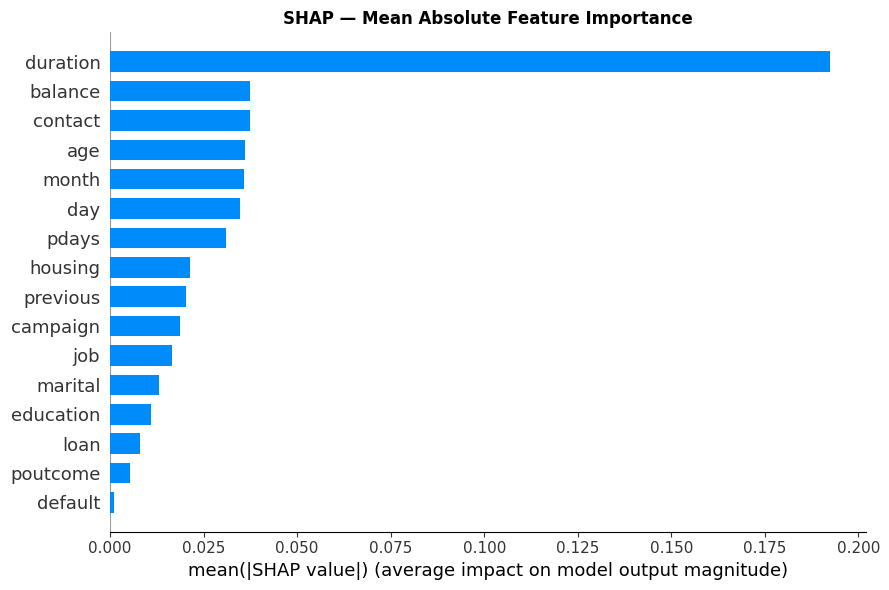

In [21]:
# SHAP Bar Plot — Global Feature Importance
# Shows the mean absolute SHAP value per feature (overall influence)
# Easier to read than the dot plot when you just want a ranked list
plt.figure(figsize=(9, 6))
shap.summary_plot(sv, X_sample,
                  feature_names=X.columns.tolist(),
                  plot_type='bar', show=False, plot_size=None)
plt.title("SHAP — Mean Absolute Feature Importance", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


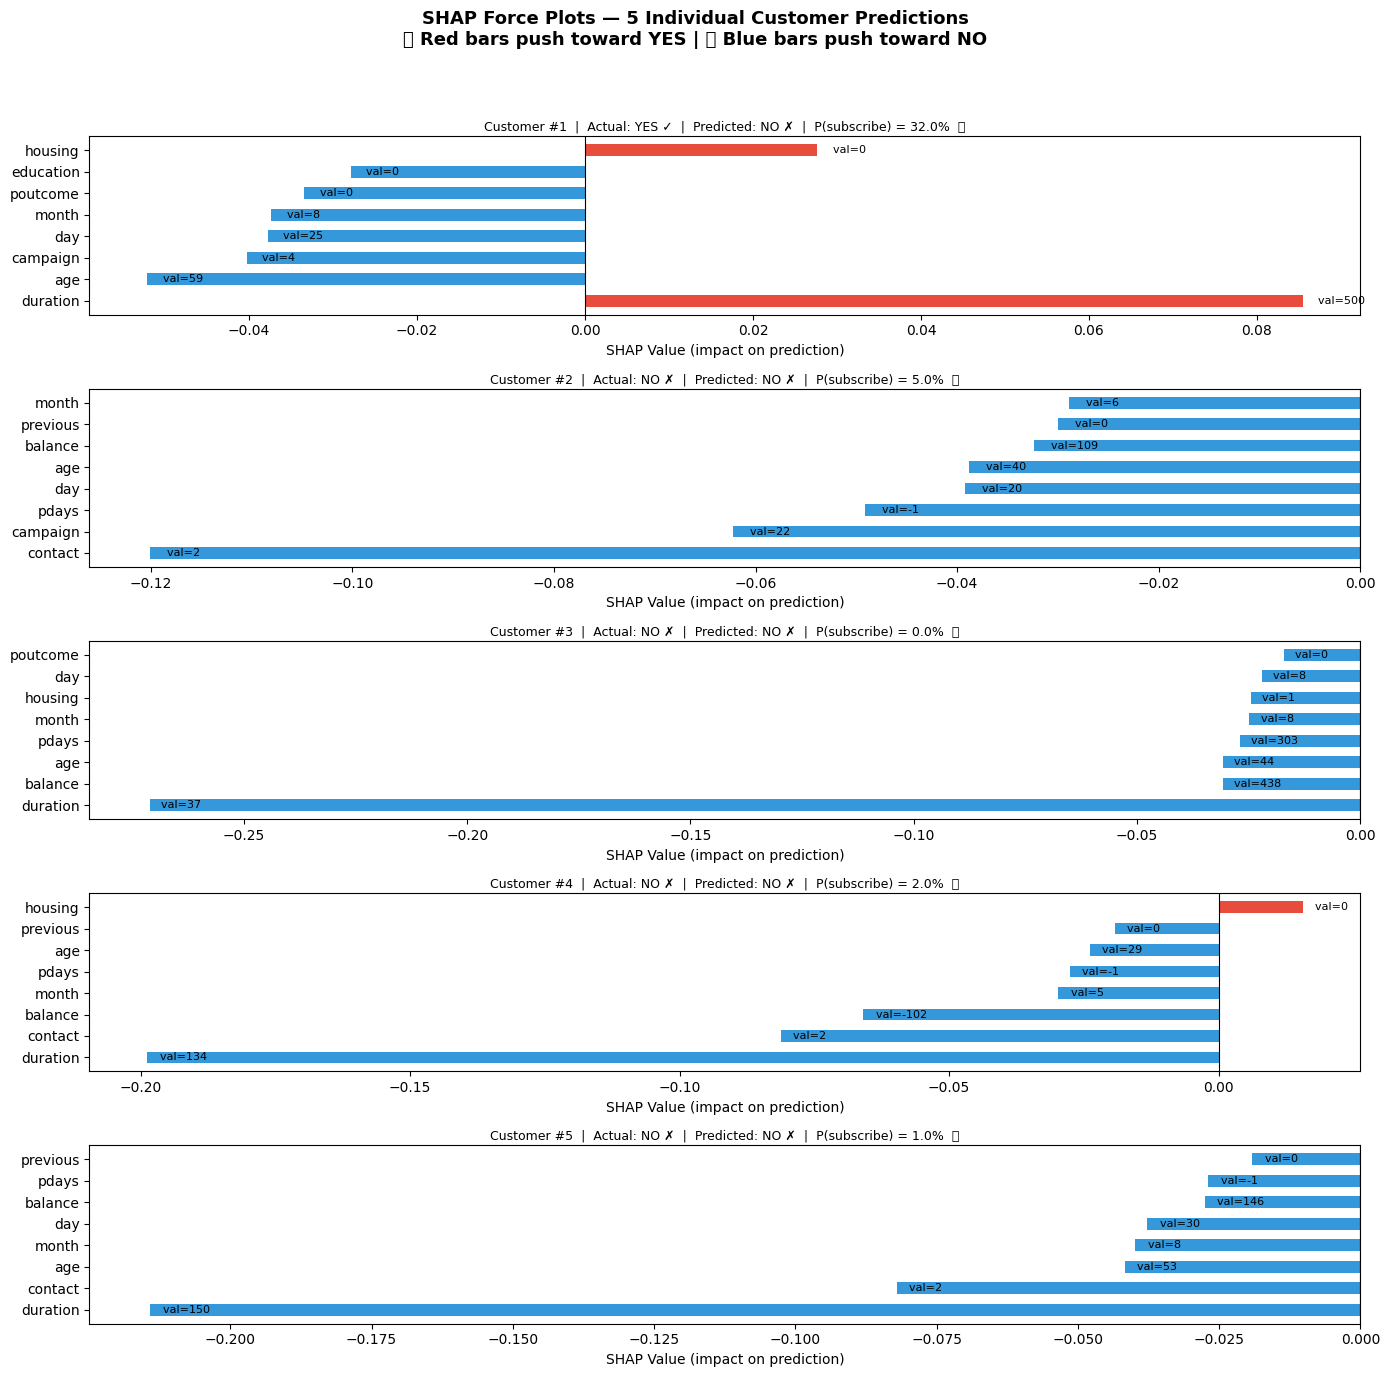

In [22]:
# Force plots for 5 INDIVIDUAL customers
# Shows exactly which features pushed the prediction up (red) or down (blue)

fig, axes = plt.subplots(5, 1, figsize=(14, 14))
fig.suptitle(
    "SHAP Force Plots — 5 Individual Customer Predictions\n"
    "🔴 Red bars push toward YES | 🔵 Blue bars push toward NO",
    fontsize=13, fontweight='bold'
)

for i in range(5):
    ax = axes[i]
    shap_vals_i  = sv[i]
    feature_vals = X_sample.iloc[i].values

    # Sort features by absolute SHAP value (most impactful first)
    order = np.argsort(np.abs(shap_vals_i))[::-1][:8]  # show top 8 features
    feat_names  = [X.columns[j] for j in order]
    feat_shap   = [shap_vals_i[j] for j in order]
    feat_actual = [feature_vals[j] for j in order]

    bar_colors = ['#e74c3c' if v > 0 else '#3498db' for v in feat_shap]
    bars = ax.barh(feat_names, feat_shap, color=bar_colors, height=0.55)

    # Annotate each bar with the actual raw feature value
    for bar, val in zip(bars, feat_actual):
        x_pos = bar.get_width()
        ax.text(x_pos + 0.001, bar.get_y() + bar.get_height()/2,
                f'  val={val:.0f}', va='center', fontsize=8)

    actual    = "YES ✓" if y_test.iloc[i] == 1 else "NO ✗"
    predicted = "YES ✓" if y_pred_rf[i] == 1 else "NO ✗"
    prob      = y_prob_rf[i]
    match     = "✅" if y_test.iloc[i] == y_pred_rf[i] else "❌"

    ax.set_title(
        f"Customer #{i+1}  |  Actual: {actual}  |  Predicted: {predicted}  "
        f"|  P(subscribe) = {prob:.1%}  {match}",
        fontsize=9, pad=4
    )
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel("SHAP Value (impact on prediction)")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [23]:
# Print a readable text summary for each of the 5 customers
print("=" * 65)
print("SHAP EXPLANATION SUMMARY — 5 INDIVIDUAL PREDICTIONS")
print("=" * 65)

for i in range(5):
    actual    = "YES" if y_test.iloc[i] == 1 else "NO"
    predicted = "YES" if y_pred_rf[i] == 1 else "NO"
    prob      = y_prob_rf[i]
    result    = "✅ Correct" if y_test.iloc[i] == y_pred_rf[i] else "❌ Wrong"

    print(f"\nCustomer #{i+1}")
    print(f"  Actual: {actual} | Predicted: {predicted} | P(yes)={prob:.1%} | {result}")
    print("  Top 3 features driving this prediction:")

    order = np.argsort(np.abs(sv[i]))[::-1][:3]
    for j in order:
        feat_name = X.columns[j]
        shap_val  = sv[i][j]
        direction = "↑ toward YES" if shap_val > 0 else "↓ toward NO"
        print(f"    • {feat_name:<12} SHAP={shap_val:+.4f}  {direction}")


SHAP EXPLANATION SUMMARY — 5 INDIVIDUAL PREDICTIONS

Customer #1
  Actual: YES | Predicted: NO | P(yes)=32.0% | ❌ Wrong
  Top 3 features driving this prediction:
    • duration     SHAP=+0.0854  ↑ toward YES
    • age          SHAP=-0.0521  ↓ toward NO
    • campaign     SHAP=-0.0403  ↓ toward NO

Customer #2
  Actual: NO | Predicted: NO | P(yes)=5.0% | ✅ Correct
  Top 3 features driving this prediction:
    • contact      SHAP=-0.1201  ↓ toward NO
    • campaign     SHAP=-0.0622  ↓ toward NO
    • pdays        SHAP=-0.0492  ↓ toward NO

Customer #3
  Actual: NO | Predicted: NO | P(yes)=0.0% | ✅ Correct
  Top 3 features driving this prediction:
    • duration     SHAP=-0.2710  ↓ toward NO
    • balance      SHAP=-0.0308  ↓ toward NO
    • age          SHAP=-0.0308  ↓ toward NO

Customer #4
  Actual: NO | Predicted: NO | P(yes)=2.0% | ✅ Correct
  Top 3 features driving this prediction:
    • duration     SHAP=-0.1988  ↓ toward NO
    • contact      SHAP=-0.0812  ↓ toward NO
    • balanc

## 📋 Section 11 — Final Model Comparison

Comparing both models across all key metrics to decide which one to use in production.

In [24]:
# Compute all metrics for both models in one place
results = {}
for name, y_pred, y_prob in [
    ("Logistic Regression", y_pred_lr, y_prob_lr),
    ("Random Forest",       y_pred_rf, y_prob_rf),
]:
    results[name] = {
        "Accuracy" : accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall"   : recall_score(y_test, y_pred),
        "F1-Score" : f1_score(y_test, y_pred),
        "ROC-AUC"  : roc_auc_score(y_test, y_prob),
    }

summary_df = pd.DataFrame(results).T.round(4)
print(summary_df)


                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7812     0.3089  0.7308    0.4343   0.8467
Random Forest          0.8884     0.5429  0.1827    0.2734   0.9053


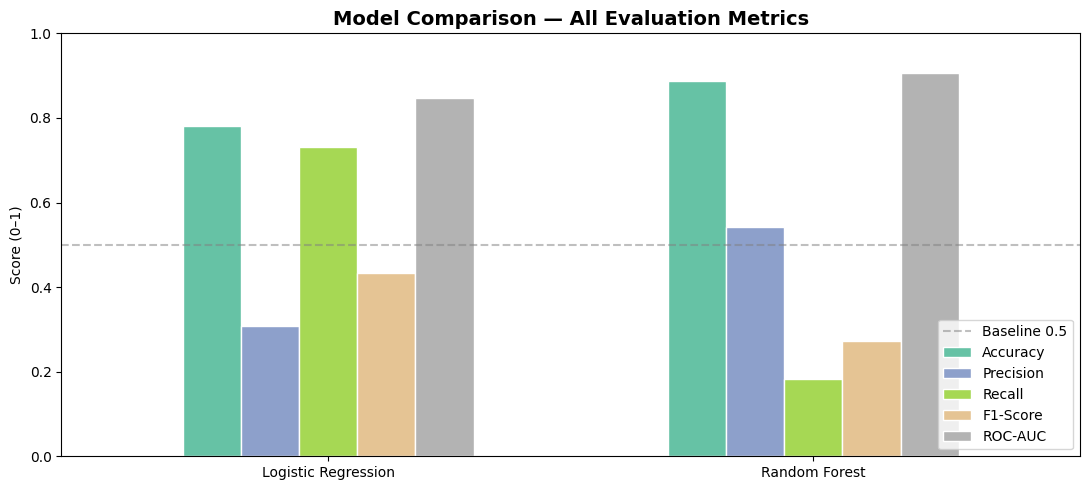


🎓 Key Insights:
  • Random Forest has higher Accuracy and ROC-AUC (better at ranking)
  • Logistic Regression has higher Recall for 'Yes' class (catches more subscribers)
  • For a marketing campaign, high Recall matters more — we don't want to miss customers
  • Both models beat the 0.5 random baseline significantly


In [25]:
# Visual bar chart comparison
ax = summary_df.plot(kind='bar', figsize=(11, 5), rot=0,
                     colormap='Set2', width=0.6, edgecolor='white')
plt.title("Model Comparison — All Evaluation Metrics", fontsize=14, fontweight='bold')
plt.ylabel("Score (0–1)")
plt.ylim(0, 1.0)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Baseline 0.5')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

print("\n🎓 Key Insights:")
print("  • Random Forest has higher Accuracy and ROC-AUC (better at ranking)")
print("  • Logistic Regression has higher Recall for 'Yes' class (catches more subscribers)")
print("  • For a marketing campaign, high Recall matters more — we don't want to miss customers")
print("  • Both models beat the 0.5 random baseline significantly")


---
## ✅ Summary

| What we did | Why |
|---|---|
| Loaded dataset with `sep=";"` | The file uses semicolons, not commas |
| Checked for missing values | Must be clean before ML |
| Visualized EDA charts | Understand patterns before modeling |
| Applied LabelEncoder | ML models require numeric inputs |
| Used `stratify=y` in split | Keeps class ratio equal in train/test |
| Used `class_weight='balanced'` | Handles imbalanced data (88% No, 12% Yes) |
| Confusion Matrix | Understand TP/FP/TN/FN breakdown |
| F1-Score | Better than accuracy for imbalanced classes |
| ROC-AUC | Measures how well model ranks predictions |
| SHAP values | Explain WHY the model made each prediction |

### 🏆 Best Model: Random Forest
- Higher AUC (0.905 vs 0.849)
- More reliable overall performance
- SHAP reveals `duration`, `balance`, and `age` are the most influential features
